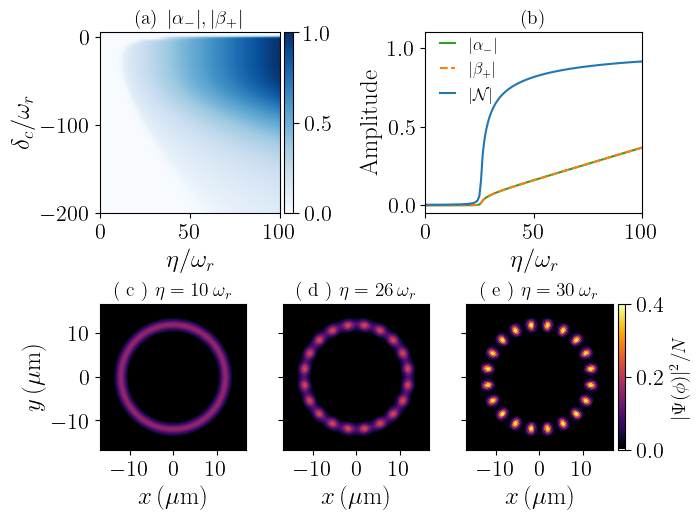

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator

# ============================================================
# Load data
# ============================================================
data = np.load(r"D:\Github_data\Figure2_data.npz")

# Panel (a)
eta_valve   = data["eta_valve"]
delta_valve = data["delta_valve"]
alpha_minuss = data["alpha_minuss"]
omega_rr    = data["omega_rr"]

# Panel (b)
eta_vals = data["eta_vals"]
a_minus_ss = data["a_minus_ss"]
b_plus_ss = data["b_plus_ss"]
Nop_ss = data["Nop_ss"]
omega_r = data["omega_r"]

# Panels (c,d,e)
X = data["X"]
Y = data["Y"]
snapshots = data["snapshots"]
eta_list = data["eta_list"]
N = data["N"]

# ============================================================
# Global plotting style
# ============================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ============================================================
# Main Grid
# ============================================================
fig = plt.figure(figsize=(7, 5.5))
gs = GridSpec(2, 3, height_ratios=[1.6, 1.4], hspace=0.5, wspace=0.25)

# ============================================================
# Split FIRST ROW into 2 equal panels
# ============================================================
gs_top = gs[0, :].subgridspec(1, 2, wspace=0.50)

# ============================================================
# (a) Contour plot
# ============================================================
ax_a = fig.add_subplot(gs_top[0, 0])

Eta, Delta = np.meshgrid(
    eta_valve / omega_rr,
    delta_valve / omega_rr,
    indexing='ij'
)

c = ax_a.contourf(
    Eta,
    Delta,
    np.abs(alpha_minuss),
    levels=300,
    cmap="Blues"
)

ax_a.set_xlabel(r"$\eta/\omega_r$")
ax_a.set_ylabel(r"$\delta_c/\omega_r$")
ax_a.set_title(r"(a)\, $|\alpha_-|, |\beta_+|$", fontsize=14, pad=6)

cbar_a = fig.colorbar(c, ax=ax_a, pad=0.02)
cbar_a.locator = MaxNLocator(nbins=3)
cbar_a.update_ticks()
cbar_a.set_ticks([0, 0.5, 1])
cbar_a.ax.tick_params(length=4)

# ============================================================
# (b) Steady-state vs eta
# ============================================================
ax_b = fig.add_subplot(gs_top[0, 1])

ax_b.plot(eta_vals / omega_r, a_minus_ss, lw=1.5, color='tab:green', label=r'$|\alpha_-|$')
ax_b.plot(eta_vals / omega_r, b_plus_ss,  lw=1.5, color='tab:orange', ls='--', label=r'$|\beta_+|$')
ax_b.plot(eta_vals / omega_r, Nop_ss, lw=1.5, color='tab:blue',
          label=r'$|\mathcal{N}|$')

ax_b.set_xlabel(r'$\eta / \omega_r$')
ax_b.set_ylabel(r'Amplitude')
ax_b.set_ylim([-0.05, 1.1])
ax_b.set_xlim([0, 100])
ax_b.legend(frameon=False, loc='upper left', handlelength=0.9,
            bbox_to_anchor=(0.0, 1.06))
ax_b.set_title(r"(b)", fontsize=14, pad=6)

# ============================================================
# (c,d,e) Bottom row
# ============================================================

vmin = np.nanmin(snapshots)
vmax = np.nanmax(snapshots)

axes_bottom = []

for j in range(3):

    ax = fig.add_subplot(gs[1, j])
    axes_bottom.append(ax)

    cmap = plt.cm.inferno.copy()
    cmap.set_bad(alpha=0)

    im = ax.pcolormesh(
        X * 1e6,
        Y * 1e6,
        snapshots[j] / N,
        cmap=cmap,
        shading='auto',
        vmin=vmin / N,
        vmax=vmax / N
    )

    ax.set_facecolor('black')
    ax.set_aspect('equal')

    ax.set_xticks([-10, 0, 10])
    ax.set_yticks([-10, 0, 10])

    ax.set_title(
        f"( {chr(99+j)} ) $\\eta = {int(eta_list[j]/omega_r)}\\,\\omega_r$",
        fontsize=14
    )

    ax.set_xlabel(r'$x\,(\mu\mathrm{m})$')

    if j == 0:
        ax.set_ylabel(r'$y\,(\mu\mathrm{m})$')
    else:
        ax.set_yticklabels([])

# ============================================================
# Shared colorbar
# ============================================================
cbar = fig.colorbar(
    im,
    ax=axes_bottom,
    fraction=0.045,
    shrink=0.92,
    pad=0.01
)

cbar.set_label(r'$|\Psi(\phi)|^2/N$', fontsize=14)
cbar.set_ticks([0.0, 0.2, 0.4])
cbar.ax.tick_params(length=4)

# ============================================================
# Show
# ============================================================
plt.show()